In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
class LinSet:
    def __init__(self, x_origin=None, facet=5, radius=1.0, random_bias=True):
        self.x_origin = x_origin if x_origin is not None else np.array([0.0, 0.0])
        if random_bias:
            bias = np.random.rand() * 2 * np.pi / facet
        else:
            bias = 0
        
        theta = np.linspace(bias, 2*np.pi + bias, facet, endpoint=False)
        self.A = np.array([[np.cos(t), np.sin(t)] for t in theta])  # Normals to facets
        self.b = np.ones(facet) * radius  # Distances from origin to facets

    def check_feasibility(self, x):
        """Check if point x is in the convex set"""
        x_shifted = x - self.x_origin
        return (x_shifted @ self.A.T) - self.b

    def point_to_boundary_dist(self, u):
        """Find boundary distance along direction u from origin"""
        u = np.atleast_2d(u)
        dot_products = u @ self.A.T
        
        # Consider only directions where dot_product is positive
        mask = dot_products > 1e-9
        distances = np.full_like(dot_products, np.inf)
        distances[mask] = (self.b / dot_products)[mask]
        
        min_dists = np.min(distances, axis=1, keepdims=True)
        return min_dists

    def point_to_boundary_dist_with_facet(self, u):
        """Find boundary distance and the active facet index along direction u."""
        u = np.atleast_2d(u)
        dot_products = u @ self.A.T
        
        mask = dot_products > 1e-9
        distances = np.full_like(dot_products, np.inf)
        distances[mask] = (self.b / dot_products)[mask]
        
        min_dists = np.min(distances, axis=1, keepdims=True)
        facet_indices = np.argmin(distances, axis=1)
        
        return min_dists, facet_indices

class StarSet:
    def __init__(self, x_origin=None, alpha=0.3, num_star=5):
        self.x_origin = x_origin if x_origin is not None else np.array([0.0, 0.0])
        self.alpha = alpha
        self.num_star = num_star
        
    def scaling(self, x):
        """Compute the scaling factor gamma for star-shaped set"""
        x = np.atleast_2d(x)
        # Handle points at origin
        norms = np.linalg.norm(x, axis=1, keepdims=True)
        mask = norms.flatten() > 1e-10
        
        scaling = np.ones((x.shape[0], 1))
        if np.any(mask):
            x_valid = x[mask]
            theta = np.arctan2(x_valid[:, 1], x_valid[:, 0])
            scaling[mask] = (1 + self.alpha * np.sin(self.num_star * theta)).reshape(-1, 1)
        
        return scaling
        
    def point_to_boundary_dist(self, u):
        """Find boundary distance along direction u from x_origin for star-shaped set"""
        u = np.atleast_2d(u)
        batch = u.shape[0]
        
        # For star-shaped sets, we can compute this analytically
        # The boundary is defined by r = scaling(θ) where θ = arctan2(u_y, u_x)
        theta = np.arctan2(u[:, 1], u[:, 0])
        boundary_scaling = 1 + self.alpha * np.sin(self.num_star * theta)
        
        # Distance from origin to boundary in direction u
        return boundary_scaling.reshape(-1, 1)

class GaugeMap:
    def __init__(self, convex_set, p_norm=np.inf):
        """Initialize gauge map with a convex set and norm
        Args:
            convex_set: ConvexSet object defining the target space
            p_norm: The norm to use for scaling (default: inf-norm)
        """
        self.set = convex_set
        self.p_norm = p_norm
    
    def forward(self, z):
        """Map points from unit ball to convex set"""
        scaling = self._compute_scaling(z, forward=True)
        return scaling * z + self.set.x_origin
    
    def inverse(self, x):
        """Map points from convex set to unit ball"""
        x_shifted = x - self.set.x_origin
        scaling = self._compute_scaling(x_shifted, forward=False)
        return scaling * x_shifted
    
    def _compute_scaling(self, x, forward=True):
        """Calculate scaling factor for gauge function and its inverse"""
        x_norm = np.linalg.norm(x, axis=1, ord=2, keepdims=True)
        z_norm = np.linalg.norm(x, axis=1, ord=self.p_norm, keepdims=True)
        
        # Avoid division by zero
        mask = x_norm > 1e-10
        u_dir = np.zeros_like(x)
        u_dir[mask.flatten()] = x[mask.flatten()] / x_norm[mask.flatten()]
        
        # Get boundary distances
        boundary_dist = self.set.point_to_boundary_dist(u_dir)
        
        if forward:
            scaling = np.where(mask, z_norm / x_norm * boundary_dist, 0)
        else:
            scaling = np.where(mask, x_norm / (z_norm * boundary_dist + 1e-10), 0)
        
        return scaling


In [8]:
class IntersectionSet:
    def __init__(self, set1, set2):
        if not hasattr(set1, 'point_to_boundary_dist') or not hasattr(set2, 'point_to_boundary_dist'):
            raise TypeError("Both sets must have a 'point_to_boundary_dist' method.")
        if not np.array_equal(set1.x_origin, set2.x_origin):
            raise ValueError("Both sets must share the same origin for their intersection to be star-convex.")
            
        self.set1 = set1
        self.set2 = set2
        self.x_origin = set1.x_origin

    def point_to_boundary_dist(self, u):
        """
        Calculates the distance to the boundary of the intersection of two sets.
        The distance in a given direction is the minimum of the distances to the boundaries of the individual sets.
        """
        dist1 = self.set1.point_to_boundary_dist(u)
        dist2 = self.set2.point_to_boundary_dist(u)
        
        return np.minimum(dist1, dist2)


In [26]:
def visualize_intersection_mapping(star_set, lin_set, p_norm=2, n_points=2000):
    intersection_set = IntersectionSet(star_set, lin_set)
    gauge = GaugeMap(intersection_set, p_norm=p_norm)
    
    theta = np.linspace(0, 2 * np.pi, n_points)
    u_dirs = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    
    # Get distances and active constraints
    dist_star = star_set.point_to_boundary_dist(u_dirs)
    dist_lin, facet_indices = lin_set.point_to_boundary_dist_with_facet(u_dirs)
    dist_intersection = np.minimum(dist_star, dist_lin)
    
    # Determine which set is active for each direction
    is_star_active = dist_star <= dist_lin
    
    # Boundary points of the intersection
    boundary_points = u_dirs * dist_intersection
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: The intersection set and its boundaries
    ax1.set_title('Intersection of Star-Convex Set and Polytope')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    
    # Colors for polytope facets
    n_facets = len(lin_set.A)
    facet_colors = plt.cm.rainbow(np.linspace(0, 1, n_facets))
    star_color = 'gray'
    
    # Plot boundaries segment by segment
    for i in range(n_points - 1):
        p1 = boundary_points[i]
        p2 = boundary_points[i+1]
        
        # Check active constraint for the midpoint of the segment
        mid_point_active_star = is_star_active[(i + i + 1) // 2]
        
        if mid_point_active_star:
            color = star_color
            label = 'Star-Set Boundary'
        else:
            facet_idx = facet_indices[(i + i + 1) // 2]
            color = facet_colors[facet_idx]
            label = f'Polytope Facet {facet_idx + 1}'
            
        ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=2.5)

    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=star_color, lw=2, label='Star-Set Boundary')]
    legend_elements += [Line2D([0], [0], color=facet_colors[i], lw=2, label=f'Facet {i+1}') for i in range(n_facets)]
    ax1.legend(handles=legend_elements, loc='upper right')
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")

    # Plot 2: Mapped to the unit ball
    ax2.set_title('Mapped to Unit Ball')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    
    mapped_boundary_points = gauge.inverse(boundary_points)
    
    for i in range(n_points - 1):
        p1 = mapped_boundary_points[i]
        p2 = mapped_boundary_points[i+1]
        
        mid_point_active_star = is_star_active[(i + i + 1) // 2]
        
        if mid_point_active_star:
            color = star_color
        else:
            facet_idx = facet_indices[(i + i + 1) // 2]
            color = facet_colors[facet_idx]
            
        ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=2.5)

    ax2.legend(handles=legend_elements, loc='upper right')
    ax2.set_xlabel("z1")
    ax2.set_ylabel("z2")
    
    plt.tight_layout()
    plt.show()


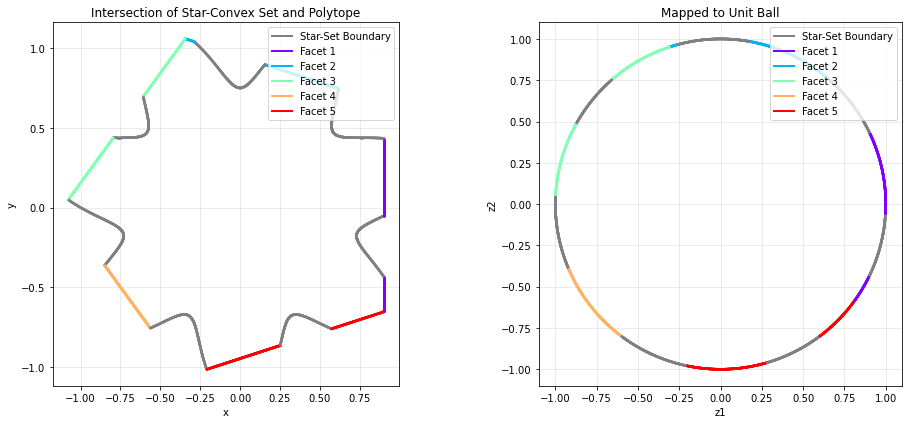

In [28]:
if __name__ == "__main__":
    # Define a star-convex set
    star_set = StarSet(alpha=0.25, num_star=7)
    
    # Define a polytope
    # Using random_bias=False to make it a regular polygon for clarity
    polytope = LinSet(facet=5, radius=0.9, random_bias=False)
    
    # Run the visualization
    visualize_intersection_mapping(star_set, polytope)
